In [2]:
import pandas as pd
import numpy as np

import requests
from bs4 import BeautifulSoup

from pathlib import Path
from time import sleep
from io import StringIO

from tqdm.notebook import tqdm
import lxml

import re
import json
import time

In [3]:
# ============================================================
# PARAMÈTRES GÉNÉRAUX
# ============================================================

START_YEAR = 2016
END_YEAR = 2025

YEARS = range(START_YEAR, END_YEAR + 1)

# Disciplines World Athletics
DISCIPLINES = {
    "long_jump": "long-jump",
    "triple_jump": "triple-jump",
    "high_jump": "high-jump",
    "pole_vault": "pole-vault",
}

# Sexes
GENDERS = {
    "men": "men",
    "women": "women",
}

# Nombre maximum de pages à parcourir.
# None = on essaie de détecter automatiquement le nombre de pages.
MAX_PAGES = None

# Temps d'attente entre deux requêtes
REQUEST_DELAY = 1.0

In [4]:
# ============================================================
# ARBORESCENCE DU PROJET
# ============================================================

BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
LOG_DIR = DATA_DIR / "logs"

for directory in [
    DATA_DIR,
    RAW_DIR,
    PROCESSED_DIR,
    LOG_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Dossier du projet :", BASE_DIR)
print("Données brutes    :", RAW_DIR)
print("Données traitées  :", PROCESSED_DIR)

Dossier du projet : C:\Users\USER\Olympics\disciplines\3-athletics-jump
Données brutes    : C:\Users\USER\Olympics\disciplines\3-athletics-jump\data\raw
Données traitées  : C:\Users\USER\Olympics\disciplines\3-athletics-jump\data\processed


In [5]:
# ============================================================
# CONSTRUCTION DES URLS WORLD ATHLETICS
# ============================================================

BASE_URL = (
    "https://worldathletics.org/records/toplists/"
    "jumps/{discipline}/outdoor/{gender}/senior/{year}"
)


def build_url(discipline, gender, year, page=None):
    """
    Construit l'URL d'une Top List World Athletics.
    """
    
    url = BASE_URL.format(
        discipline=discipline,
        gender=gender,
        year=year
    )
    
    if page is not None and page > 1:
        url += f"?page={page}"
    
    return url

In [6]:
url = build_url(
    discipline="long-jump",
    gender="men",
    year=2025
)

print(url)

https://worldathletics.org/records/toplists/jumps/long-jump/outdoor/men/senior/2025


In [7]:
# ============================================================
# CONFIGURATION HTTP
# ============================================================

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 "
        "(Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 "
        "(KHTML, like Gecko) "
        "Chrome/131.0 Safari/537.36"
    ),
    "Accept-Language": "en-US,en;q=0.9",
    "Accept": (
        "text/html,application/xhtml+xml,"
        "application/xml;q=0.9,image/webp,*/*;q=0.8"
    ),
}

In [8]:
# ============================================================
# SESSION HTTP
# ============================================================

session = requests.Session()
session.headers.update(HEADERS)

print("Session HTTP créée.")

Session HTTP créée.


In [9]:
# ============================================================
# TEST DE CONNEXION
# ============================================================

test_url = build_url(
    discipline="long-jump",
    gender="men",
    year=2025
)

response = session.get(
    test_url,
    timeout=30
)

print("URL :", test_url)
print("Status HTTP :", response.status_code)
print("Taille de la réponse :", len(response.text))

URL : https://worldathletics.org/records/toplists/jumps/long-jump/outdoor/men/senior/2025
Status HTTP : 200
Taille de la réponse : 888252


In [10]:
# ============================================================
# EXTRACTION DES TABLEAUX HTML
# ============================================================

def get_html_tables(html):
    """
    Extrait les tableaux HTML présents dans une page.
    """
    
    try:
        tables = pd.read_html(StringIO(html))
        return tables
    
    except ValueError:
        return []

In [11]:
# ============================================================
# IDENTIFICATION DU TABLEAU DE RÉSULTATS
# ============================================================

def find_results_table(tables):
    """
    Recherche le tableau contenant les résultats World Athletics.
    """
    
    for table in tables:
        
        columns = [
            str(col).strip().lower()
            for col in table.columns
        ]
        
        columns_text = " ".join(columns)
        
        if (
            "rank" in columns_text
            and "mark" in columns_text
            and "competitor" in columns_text
        ):
            return table.copy()
    
    return None

In [12]:
tables = get_html_tables(response.text)

print("Nombre de tableaux :", len(tables))

for i, table in enumerate(tables):
    print(f"\nTableau {i}")
    print(table.head())

    
results_table = find_results_table(tables)

if results_table is not None:
    print("✅ Tableau trouvé")
    display(results_table.head())
else:
    print("❌ Aucun tableau de résultats trouvé")


Nombre de tableaux : 1

Tableau 0
   Rank  Mark  WIND           Competitor          DOB Unnamed: 5   Pos  \
0     1  8.46   1.1  Miltiadis TENTOGLOU  18 MAR 1998        GRE   1f1   
1     2  8.39   0.2       Mattia FURLANI  07 FEB 2005        ITA     1   
2     3  8.34  -0.3          Tajay GAYLE  02 AUG 1996        JAM     1   
3     3  8.34   1.7        Simon EHAMMER  07 FEB 2000        SUI  1ce1   
4     3  8.34  -0.2          Liam ADCOCK  21 JUN 1996        AUS     1   

   Unnamed: 7                               Venue         Date  Results Score  
0         NaN  Estadio Vallehermoso, Madrid (ESP)  28 JUN 2025           1238  
1         NaN       National Stadium, Tokyo (JPN)  17 SEP 2025           1223  
2         NaN    National Stadium, Kingston (JAM)  22 FEB 2025           1213  
3         NaN         Mösle-Stadium, Götzis (AUT)  31 MAY 2025           1212  
4         NaN         Stadio Olimpico, Roma (ITA)  06 JUN 2025           1213  
✅ Tableau trouvé


,Rank,Mark,WIND,Competitor,DOB,Unnamed: 5,Pos,Unnamed: 7,Venue,Date,Results Score
0,1,8.46,1.1,Miltiadis TENTOGLOU,18 MAR 1998,GRE,1f1,NaN,"Estadio Vallehermoso, Madrid (ESP)",28 JUN 2025,1238
1,2,8.39,0.2,Mattia FURLANI,07 FEB 2005,ITA,1,NaN,"National Stadium, Tokyo (JPN)",17 SEP 2025,1223
2,3,8.34,-0.3,Tajay GAYLE,02 AUG 1996,JAM,1,NaN,"National Stadium, Kingston (JAM)",22 FEB 2025,1213
3,3,8.34,1.7,Simon EHAMMER,07 FEB 2000,SUI,1ce1,NaN,"Mösle-Stadium, Götzis (AUT)",31 MAY 2025,1212
4,3,8.34,-0.2,Liam ADCOCK,21 JUN 1996,AUS,1,NaN,"Stadio Olimpico, Roma (ITA)",06 JUN 2025,1213


In [13]:
# ============================================================
# NETTOYAGE DES COLONNES
# ============================================================

def clean_column_name(column):
    """
    Nettoie le nom d'une colonne.
    """
    
    column = str(column)
    
    column = (
        column
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("/", "_")
    )
    
    return column


def clean_columns(df):
    """
    Nettoie les noms de colonnes d'un DataFrame.
    """
    
    df = df.copy()
    
    df.columns = [
        clean_column_name(col)
        for col in df.columns
    ]
    
    return df

In [14]:
# ============================================================
# RÉCUPÉRATION D'UNE PAGE
# ============================================================

def fetch_page(
    discipline,
    gender,
    year,
    page=1,
    session=session
):
    """
    Récupère une page d'une Top List World Athletics.
    """
    
    url = build_url(
        discipline=discipline,
        gender=gender,
        year=year,
        page=page
    )
    
    try:
        response = session.get(
            url,
            timeout=30
        )
        
        if response.status_code != 200:
            return {
                "success": False,
                "status_code": response.status_code,
                "url": url,
                "data": None
            }
        
        tables = get_html_tables(response.text)
        
        table = find_results_table(tables)
        
        if table is None:
            return {
                "success": False,
                "status_code": response.status_code,
                "url": url,
                "data": None
            }
        
        table = clean_columns(table)
        
        return {
            "success": True,
            "status_code": response.status_code,
            "url": url,
            "data": table
        }
    
    except requests.RequestException as e:
        
        return {
            "success": False,
            "status_code": None,
            "url": url,
            "data": None,
            "error": str(e)
        }

In [15]:
result = fetch_page(
    discipline="long-jump",
    gender="men",
    year=2025,
    page=1
)

print("Succès :", result["success"])
print("Status :", result["status_code"])
print("URL :", result["url"])

if result["data"] is not None:
    display(result["data"].head(10))


Succès : True
Status : 200
URL : https://worldathletics.org/records/toplists/jumps/long-jump/outdoor/men/senior/2025


,rank,mark,wind,competitor,dob,unnamed:_5,pos,unnamed:_7,venue,date,results_score
0,1,8.46,1.1,Miltiadis TENTOGLOU,18 MAR 1998,GRE,1f1,NaN,"Estadio Vallehermoso, Madrid (ESP)",28 JUN 2025,1238
1,2,8.39,0.2,Mattia FURLANI,07 FEB 2005,ITA,1,NaN,"National Stadium, Tokyo (JPN)",17 SEP 2025,1223
2,3,8.34,-0.3,Tajay GAYLE,02 AUG 1996,JAM,1,NaN,"National Stadium, Kingston (JAM)",22 FEB 2025,1213
3,3,8.34,1.7,Simon EHAMMER,07 FEB 2000,SUI,1ce1,NaN,"Mösle-Stadium, Götzis (AUT)",31 MAY 2025,1212
4,3,8.34,-0.2,Liam ADCOCK,21 JUN 1996,AUS,1,NaN,"Stadio Olimpico, Roma (ITA)",06 JUN 2025,1213
5,3,8.34,0.2,Jorge A. HODELÍN,16 MAY 2007,CUB,1,NaN,"Pista Rafael Fortun Chacon, Camagüey (CUB)",29 JUN 2025,1212
6,7,8.33,1.6,Carey MCLEOD,14 APR 1998,JAM,1,NaN,"Piedmont Park, Atlanta, GA (USA)",17 MAY 2025,1210
7,7,8.33,0.0,Yuhao SHI,26 SEP 1998,CHN,3,NaN,"National Stadium, Tokyo (JPN)",17 SEP 2025,1210
8,9,8.29,NaN,Wayne PINNOCK,24 OCT 2000,JAM,2,NaN,"Sports Training Center, Nanjing (CHN) (i)",23 MAR 2025,1201
9,10,8.27,0.7,Tom CAMPAGNE,14 NOV 2000,FRA,1,NaN,"Stade Pierre Paul Bernard, Talence (FRA)",02 AUG 2025,1197


In [16]:
# ============================================================
# DÉTECTION DU NOMBRE DE PAGES
# ============================================================

def detect_number_of_pages(html):
    """
    Essaie de détecter le nombre maximal de pages
    dans le HTML World Athletics.
    """
    
    # Recherche de motifs du type :
    # 1 2 3 ... 48
    patterns = [
        r'page=(\d+)',
        r'pageNumber=(\d+)',
    ]
    
    pages = []
    
    for pattern in patterns:
        matches = re.findall(pattern, html)
        
        for match in matches:
            try:
                pages.append(int(match))
            except ValueError:
                pass
    
    if pages:
        return max(pages)
    
    return None

In [17]:
# ============================================================
# RÉCUPÉRATION DE TOUTES LES PAGES
# ============================================================

def fetch_all_pages(
    discipline,
    gender,
    year,
    max_pages=None,
    delay=REQUEST_DELAY
):
    """
    Récupère toutes les pages d'une Top List.
    """
    
    all_pages = []
    
    page = 1
    
    while True:
        
        print(
            f"{year} | "
            f"{gender} | "
            f"{discipline} | "
            f"page {page}"
        )
        
        result = fetch_page(
            discipline=discipline,
            gender=gender,
            year=year,
            page=page
        )
        
        # Échec
        if not result["success"]:
            
            print(
                f"⚠️ Échec page {page} "
                f"(HTTP {result['status_code']})"
            )
            
            break
        
        df_page = result["data"]
        
        # Page vide
        if df_page is None or df_page.empty:
            print("Page vide → fin.")
            break
        
        all_pages.append(df_page)
        
        # Si max_pages est défini
        if max_pages is not None:
            if page >= max_pages:
                break
        
        # Une page contenant moins de résultats
        # peut indiquer la dernière page.
        if len(df_page) == 0:
            break
        
        page += 1
        
        sleep(delay)
    
    if not all_pages:
        return pd.DataFrame()
    
    return pd.concat(
        all_pages,
        ignore_index=True
    )

In [18]:
df_test = fetch_all_pages(
    discipline="long-jump",
    gender="men",
    year=2025,
    max_pages=3
)

print("Nombre de lignes :", len(df_test))

display(df_test.head())


2025 | men | long-jump | page 1
2025 | men | long-jump | page 2
2025 | men | long-jump | page 3
Nombre de lignes : 300


,rank,mark,wind,competitor,dob,unnamed:_5,pos,unnamed:_7,venue,date,results_score
0,1,8.46,1.1,Miltiadis TENTOGLOU,18 MAR 1998,GRE,1f1,NaN,"Estadio Vallehermoso, Madrid (ESP)",28 JUN 2025,1238
1,2,8.39,0.2,Mattia FURLANI,07 FEB 2005,ITA,1,NaN,"National Stadium, Tokyo (JPN)",17 SEP 2025,1223
2,3,8.34,-0.3,Tajay GAYLE,02 AUG 1996,JAM,1,NaN,"National Stadium, Kingston (JAM)",22 FEB 2025,1213
3,3,8.34,1.7,Simon EHAMMER,07 FEB 2000,SUI,1ce1,NaN,"Mösle-Stadium, Götzis (AUT)",31 MAY 2025,1212
4,3,8.34,-0.2,Liam ADCOCK,21 JUN 1996,AUS,1,NaN,"Stadio Olimpico, Roma (ITA)",06 JUN 2025,1213


In [19]:
# ============================================================
# AJOUT DES MÉTADONNÉES
# ============================================================

def add_metadata(
    df,
    discipline,
    gender,
    year
):
    """
    Ajoute les informations permettant d'identifier
    précisément chaque observation.
    """
    
    df = df.copy()
    
    discipline_labels = {
        "long-jump": "Saut en longueur",
        "triple-jump": "Triple saut",
        "high-jump": "Saut en hauteur",
        "pole-vault": "Saut à la perche",
    }
    
    gender_labels = {
        "men": "Hommes",
        "women": "Femmes",
    }
    
    df["year"] = year
    df["gender"] = gender_labels.get(gender, gender)
    df["discipline"] = discipline_labels.get(
        discipline,
        discipline
    )
    
    return df

In [20]:
# ============================================================
# NETTOYAGE DES PERFORMANCES
# ============================================================

def parse_mark(value):
    """
    Transforme une performance World Athletics
    en valeur numérique.

    Exemples :
    '8.46' -> 8.46
    '2.37' -> 2.37
    '18.21' -> 18.21
    """
    
    if pd.isna(value):
        return np.nan
    
    value = str(value).strip()
    
    # Garder uniquement les chiffres et le point
    match = re.search(r'\d+(?:\.\d+)?', value)
    
    if match:
        return float(match.group())
    
    return np.nan

In [21]:
# ============================================================
# NETTOYAGE DU VENT
# ============================================================

def parse_wind(value):
    """
    Transforme la colonne WIND en nombre.
    
    Exemples :
    '+1.1' -> 1.1
    '-0.3' -> -0.3
    '0.0'  -> 0.0
    """
    
    if pd.isna(value):
        return np.nan
    
    value = str(value).strip()
    
    match = re.search(
        r'[-+]?\d+(?:\.\d+)?',
        value
    )
    
    if match:
        return float(match.group())
    
    return np.nan

In [22]:
# ============================================================
# NETTOYAGE D'UNE TOP LIST
# ============================================================

def clean_results(df):
    """
    Nettoyage général des résultats.
    """
    
    df = df.copy()
    
    # Performance
    if "mark" in df.columns:
        df["mark"] = df["mark"].apply(parse_mark)
    
    # Vent
    if "wind" in df.columns:
        df["wind"] = df["wind"].apply(parse_wind)
    
    # Rank
    if "rank" in df.columns:
        df["rank"] = pd.to_numeric(
            df["rank"],
            errors="coerce"
        )
    
    # Results Score
    if "results_score" in df.columns:
        df["results_score"] = pd.to_numeric(
            df["results_score"],
            errors="coerce"
        )
    
    return df

In [23]:
# ============================================================
# URL SOURCE
# ============================================================

def add_source_url(
    df,
    discipline,
    gender,
    year
):
    """
    Ajoute l'URL World Athletics correspondant
    à chaque observation.
    """
    
    df = df.copy()
    
    df["source_url"] = build_url(
        discipline=discipline,
        gender=gender,
        year=year
    )
    
    return df

In [24]:
# ============================================================
# SAUVEGARDE
# ============================================================

def save_raw_data(
    df,
    discipline,
    gender,
    year
):
    """
    Sauvegarde les données brutes d'une Top List.
    """
    
    year_dir = RAW_DIR / str(year)
    year_dir.mkdir(
        parents=True,
        exist_ok=True
    )
    
    filename = (
        f"{year}_"
        f"{gender}_"
        f"{discipline}.csv"
    )
    
    filepath = year_dir / filename
    
    df.to_csv(
        filepath,
        index=False,
        encoding="utf-8-sig"
    )
    
    return filepath

In [25]:
# ============================================================
# PIPELINE COMPLET
# ============================================================

def collect_toplist(
    discipline,
    gender,
    year,
    max_pages=None
):
    """
    Collecte et nettoie une Top List complète.
    """
    
    df = fetch_all_pages(
        discipline=discipline,
        gender=gender,
        year=year,
        max_pages=max_pages
    )
    
    if df.empty:
        return pd.DataFrame()
    
    # Nettoyage
    df = clean_results(df)
    
    # Métadonnées
    df = add_metadata(
        df,
        discipline=discipline,
        gender=gender,
        year=year
    )
    
    # URL
    df = add_source_url(
        df,
        discipline=discipline,
        gender=gender,
        year=year
    )
    
    return df

In [26]:
df_test = collect_toplist(
    discipline="long-jump",
    gender="men",
    year=2025,
    max_pages=3
)

print(
    f"{len(df_test):,} observations récupérées"
)

display(df_test.head(10))

2025 | men | long-jump | page 1
2025 | men | long-jump | page 2
2025 | men | long-jump | page 3
300 observations récupérées


,rank,mark,wind,competitor,dob,unnamed:_5,pos,unnamed:_7,venue,date,results_score,year,gender,discipline,source_url
0,1,8.46,1.1,Miltiadis TENTOGLOU,18 MAR 1998,GRE,1f1,NaN,"Estadio Vallehermoso, Madrid (ESP)",28 JUN 2025,1238,2025,Hommes,Saut en longueur,https://worldathletics.org/records/toplists/ju...
1,2,8.39,0.2,Mattia FURLANI,07 FEB 2005,ITA,1,NaN,"National Stadium, Tokyo (JPN)",17 SEP 2025,1223,2025,Hommes,Saut en longueur,https://worldathletics.org/records/toplists/ju...
2,3,8.34,-0.3,Tajay GAYLE,02 AUG 1996,JAM,1,NaN,"National Stadium, Kingston (JAM)",22 FEB 2025,1213,2025,Hommes,Saut en longueur,https://worldathletics.org/records/toplists/ju...
3,3,8.34,1.7,Simon EHAMMER,07 FEB 2000,SUI,1ce1,NaN,"Mösle-Stadium, Götzis (AUT)",31 MAY 2025,1212,2025,Hommes,Saut en longueur,https://worldathletics.org/records/toplists/ju...
4,3,8.34,-0.2,Liam ADCOCK,21 JUN 1996,AUS,1,NaN,"Stadio Olimpico, Roma (ITA)",06 JUN 2025,1213,2025,Hommes,Saut en longueur,https://worldathletics.org/records/toplists/ju...
5,3,8.34,0.2,Jorge A. HODELÍN,16 MAY 2007,CUB,1,NaN,"Pista Rafael Fortun Chacon, Camagüey (CUB)",29 JUN 2025,1212,2025,Hommes,Saut en longueur,https://worldathletics.org/records/toplists/ju...
6,7,8.33,1.6,Carey MCLEOD,14 APR 1998,JAM,1,NaN,"Piedmont Park, Atlanta, GA (USA)",17 MAY 2025,1210,2025,Hommes,Saut en longueur,https://worldathletics.org/records/toplists/ju...
7,7,8.33,0.0,Yuhao SHI,26 SEP 1998,CHN,3,NaN,"National Stadium, Tokyo (JPN)",17 SEP 2025,1210,2025,Hommes,Saut en longueur,https://worldathletics.org/records/toplists/ju...
8,9,8.29,NaN,Wayne PINNOCK,24 OCT 2000,JAM,2,NaN,"Sports Training Center, Nanjing (CHN) (i)",23 MAR 2025,1201,2025,Hommes,Saut en longueur,https://worldathletics.org/records/toplists/ju...
9,10,8.27,0.7,Tom CAMPAGNE,14 NOV 2000,FRA,1,NaN,"Stade Pierre Paul Bernard, Talence (FRA)",02 AUG 2025,1197,2025,Hommes,Saut en longueur,https://worldathletics.org/records/toplists/ju...


In [27]:
df_test[
    [
        "rank",
        "mark",
        "wind",
        "competitor",
        "venue",
        "date"
    ]
].head(20)


,rank,mark,wind,competitor,venue,date
0,1,8.46,1.1,Miltiadis TENTOGLOU,"Estadio Vallehermoso, Madrid (ESP)",28 JUN 2025
1,2,8.39,0.2,Mattia FURLANI,"National Stadium, Tokyo (JPN)",17 SEP 2025
2,3,8.34,-0.3,Tajay GAYLE,"National Stadium, Kingston (JAM)",22 FEB 2025
3,3,8.34,1.7,Simon EHAMMER,"Mösle-Stadium, Götzis (AUT)",31 MAY 2025
4,3,8.34,-0.2,Liam ADCOCK,"Stadio Olimpico, Roma (ITA)",06 JUN 2025
5,3,8.34,0.2,Jorge A. HODELÍN,"Pista Rafael Fortun Chacon, Camagüey (CUB)",29 JUN 2025
6,7,8.33,1.6,Carey MCLEOD,"Piedmont Park, Atlanta, GA (USA)",17 MAY 2025
7,7,8.33,0.0,Yuhao SHI,"National Stadium, Tokyo (JPN)",17 SEP 2025
8,9,8.29,NaN,Wayne PINNOCK,"Sports Training Center, Nanjing (CHN) (i)",23 MAR 2025
9,10,8.27,0.7,Tom CAMPAGNE,"Stade Pierre Paul Bernard, Talence (FRA)",02 AUG 2025


In [29]:
# ============================================================
# COLLECTE COMPLÈTE
# ============================================================

all_results = []

for year in YEARS:
    
    for gender in GENDERS.values():
        
        for discipline in DISCIPLINES.values():
            
            print("\n" + "=" * 70)
            print(
                f"Collecte : {year} | "
                f"{gender} | "
                f"{discipline}"
            )
            print("=" * 70)
            
            df = collect_toplist(
                discipline=discipline,
                gender=gender,
                year=year,
                max_pages=3
            )
            
            if not df.empty:
                
                all_results.append(df)
                
                print(
                    f"✅ {len(df):,} lignes récupérées"
                )
            
            else:
                
                print(
                    "⚠️ Aucune donnée récupérée"
                )


Collecte : 2016 | men | long-jump
2016 | men | long-jump | page 1
2016 | men | long-jump | page 2
2016 | men | long-jump | page 3
✅ 300 lignes récupérées

Collecte : 2016 | men | triple-jump
2016 | men | triple-jump | page 1
2016 | men | triple-jump | page 2
2016 | men | triple-jump | page 3
✅ 300 lignes récupérées

Collecte : 2016 | men | high-jump
2016 | men | high-jump | page 1
2016 | men | high-jump | page 2
2016 | men | high-jump | page 3
✅ 300 lignes récupérées

Collecte : 2016 | men | pole-vault
2016 | men | pole-vault | page 1
2016 | men | pole-vault | page 2
2016 | men | pole-vault | page 3
✅ 300 lignes récupérées

Collecte : 2016 | women | long-jump
2016 | women | long-jump | page 1
2016 | women | long-jump | page 2
2016 | women | long-jump | page 3
✅ 300 lignes récupérées

Collecte : 2016 | women | triple-jump
2016 | women | triple-jump | page 1
2016 | women | triple-jump | page 2
2016 | women | triple-jump | page 3
✅ 300 lignes récupérées

Collecte : 2016 | women | high-ju

2019 | men | pole-vault | page 2
2019 | men | pole-vault | page 3
✅ 300 lignes récupérées

Collecte : 2019 | women | long-jump
2019 | women | long-jump | page 1
2019 | women | long-jump | page 2
2019 | women | long-jump | page 3
✅ 300 lignes récupérées

Collecte : 2019 | women | triple-jump
2019 | women | triple-jump | page 1
2019 | women | triple-jump | page 2
2019 | women | triple-jump | page 3
✅ 300 lignes récupérées

Collecte : 2019 | women | high-jump
2019 | women | high-jump | page 1
2019 | women | high-jump | page 2
2019 | women | high-jump | page 3
✅ 300 lignes récupérées

Collecte : 2019 | women | pole-vault
2019 | women | pole-vault | page 1
2019 | women | pole-vault | page 2
2019 | women | pole-vault | page 3
✅ 300 lignes récupérées

Collecte : 2020 | men | long-jump
2020 | men | long-jump | page 1
2020 | men | long-jump | page 2
2020 | men | long-jump | page 3
✅ 300 lignes récupérées

Collecte : 2020 | men | triple-jump
2020 | men | triple-jump | page 1
2020 | men | triple-

2022 | women | high-jump | page 2
2022 | women | high-jump | page 3
✅ 300 lignes récupérées

Collecte : 2022 | women | pole-vault
2022 | women | pole-vault | page 1
2022 | women | pole-vault | page 2
2022 | women | pole-vault | page 3
✅ 300 lignes récupérées

Collecte : 2023 | men | long-jump
2023 | men | long-jump | page 1
2023 | men | long-jump | page 2
2023 | men | long-jump | page 3
✅ 300 lignes récupérées

Collecte : 2023 | men | triple-jump
2023 | men | triple-jump | page 1
2023 | men | triple-jump | page 2
2023 | men | triple-jump | page 3
✅ 300 lignes récupérées

Collecte : 2023 | men | high-jump
2023 | men | high-jump | page 1
2023 | men | high-jump | page 2
2023 | men | high-jump | page 3
✅ 300 lignes récupérées

Collecte : 2023 | men | pole-vault
2023 | men | pole-vault | page 1
2023 | men | pole-vault | page 2
2023 | men | pole-vault | page 3
✅ 300 lignes récupérées

Collecte : 2023 | women | long-jump
2023 | women | long-jump | page 1
2023 | women | long-jump | page 2
2023

In [30]:
# ============================================================
# FUSION
# ============================================================

if all_results:
    
    df_all = pd.concat(
        all_results,
        ignore_index=True
    )
    
else:
    
    df_all = pd.DataFrame()

print(
    f"Nombre total d'observations : "
    f"{len(df_all):,}"
)


Nombre total d'observations : 24,000


In [31]:
# ============================================================
# DOUBLONS
# ============================================================

before = len(df_all)

df_all = df_all.drop_duplicates()

after = len(df_all)

print("Avant :", before)
print("Après :", after)
print("Doublons supprimés :", before - after)

Avant : 24000
Après : 24000
Doublons supprimés : 0


In [32]:
df_all.groupby(
    ["year", "gender", "discipline"]
).size().unstack(
    fill_value=0
)

discipline   Saut en hauteur  Saut en longueur  Saut à la perche  Triple saut
year gender                                                                  
2016 Femmes              300               300               300          300
     Hommes              300               300               300          300
2017 Femmes              300               300               300          300
     Hommes              300               300               300          300
2018 Femmes              300               300               300          300
     Hommes              300               300               300          300
2019 Femmes              300               300               300          300
     Hommes              300               300               300          300
2020 Femmes              300               300               300          300
     Hommes              300               300               300          300
2021 Femmes              300               300               300          300
     Hommes              300               300               300          300
2022 Femmes              300               300               300          300
     Hommes              300               300               300          300
2023 Femmes              300               300               300          300
     Hommes              300               300               300          300
2024 Femmes              300               300               300          300
     Hommes              300               300               300          300
2025 Femmes              300               300               300          300
     Hommes              300               300               300          300

In [33]:
# ============================================================
# EXPORT CSV
# ============================================================

csv_path = (
    PROCESSED_DIR /
    "world_athletics_toplists_2016_2025.csv"
)

df_all.to_csv(
    csv_path,
    index=False,
    encoding="utf-8-sig"
)

print("Fichier sauvegardé :")
print(csv_path)

Fichier sauvegardé :
C:\Users\USER\Olympics\disciplines\3-athletics-jump\data\processed\world_athletics_toplists_2016_2025.csv


In [39]:
# ============================================================
# PARAMÈTRES
# ============================================================

START_YEAR = 2016
END_YEAR = 2025

BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"

INPUT_FILE = (
    PROCESSED_DIR /
    "world_athletics_toplists_2016_2025.csv"
)

print("Fichier source :", INPUT_FILE)
print("Existe :", INPUT_FILE.exists())

# ============================================================
# CHARGEMENT DES DONNÉES
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    encoding="utf-8-sig"
)

print(
    f"{len(df):,} lignes chargées."
)

display(df.head())

Fichier source : C:\Users\USER\Olympics\disciplines\3-athletics-jump\data\processed\world_athletics_toplists_2016_2025.csv
Existe : True
24,000 lignes chargées.


,rank,mark,wind,competitor,dob,unnamed:_5,pos,unnamed:_7,venue,date,results_score,year,gender,discipline,source_url
0,1,8.58,1.8,Jarrion LAWSON,06 MAY 1994,USA,2,NaN,"Hayward Field, Eugene, OR (USA)",03 JUL 2016,1265,2016,Hommes,Saut en longueur,https://worldathletics.org/records/toplists/ju...
1,2,8.48,0.1,Luvo MANYONGA,08 JAN 1991,RSA,1,NaN,"Boudewijnstadion, Bruxelles (BEL)",09 SEP 2016,1243,2016,Hommes,Saut en longueur,https://worldathletics.org/records/toplists/ju...
2,3,8.45,0.8,Marquise GOODWIN,19 NOV 1990,USA,1,NaN,Baie Mahault (FRA),14 MAY 2016,1236,2016,Hommes,Saut en longueur,https://worldathletics.org/records/toplists/ju...
3,4,8.44,1.8,Michel TORNÉUS,26 MAY 1986,SWE,1,NaN,Monachil (ESP),10 JUL 2016,1234,2016,Hommes,Saut en longueur,https://worldathletics.org/records/toplists/ju...
4,5,8.42,1.6,Marquis DENDY,17 NOV 1992,USA,4,NaN,"Hayward Field, Eugene, OR (USA)",03 JUL 2016,1229,2016,Hommes,Saut en longueur,https://worldathletics.org/records/toplists/ju...


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    palette="deep"
)

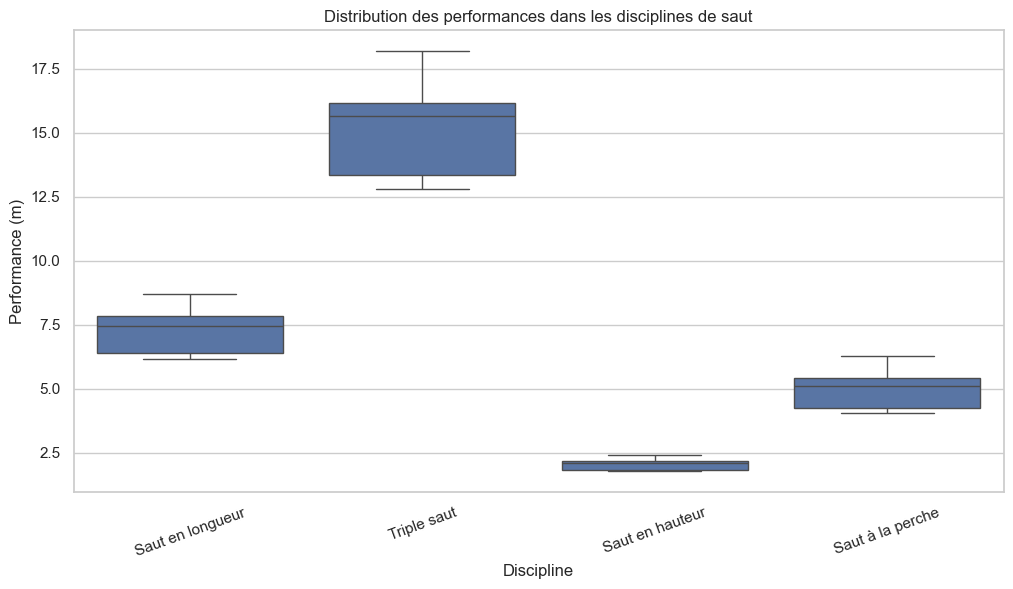

In [35]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_all,
    x="discipline",
    y="mark"
)

plt.title(
    "Distribution des performances "
    "dans les disciplines de saut"
)

plt.xlabel("Discipline")
plt.ylabel("Performance (m)")

plt.xticks(rotation=20)

plt.show()

In [36]:
best_per_year = (
    df_all
    .groupby(
        ["year", "gender", "discipline"]
    )["mark"]
    .max()
    .reset_index()
)

best_per_year.head()

,year,gender,discipline,mark
0,2016,Femmes,Saut en hauteur,2.01
1,2016,Femmes,Saut en longueur,7.31
2,2016,Femmes,Saut à la perche,5.03
3,2016,Femmes,Triple saut,15.17
4,2016,Hommes,Saut en hauteur,2.40


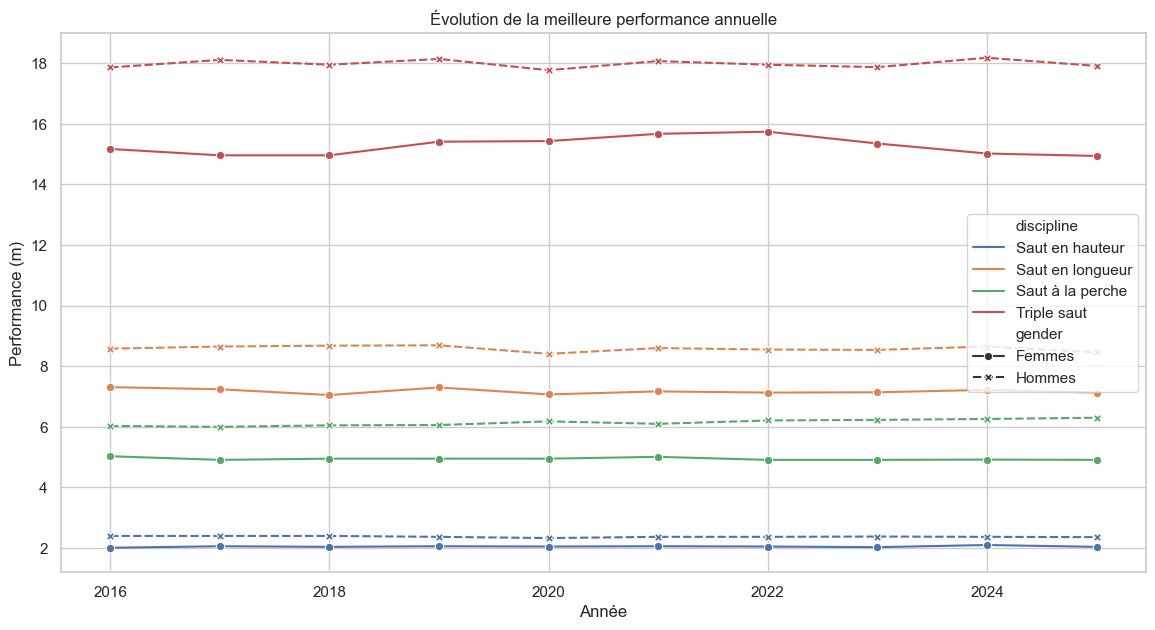

In [37]:
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=best_per_year,
    x="year",
    y="mark",
    hue="discipline",
    style="gender",
    markers=True
)

plt.title(
    "Évolution de la meilleure performance annuelle"
)

plt.xlabel("Année")
plt.ylabel("Performance (m)")

plt.show()

In [40]:
# ============================================================
# CONTRÔLE GLOBAL
# ============================================================

control = (
    df
    .groupby(
        ["year", "gender", "discipline"]
    )
    .agg(
        observations=("mark", "count"),
        athlètes=("competitor", "nunique"),
        performance_min=("mark", "min"),
        performance_max=("mark", "max")
    )
    .reset_index()
)

display(control.head(20))

,year,gender,discipline,observations,athlètes,performance_min,performance_max
0,2016,Femmes,Saut en hauteur,300,300,1.80,2.01
1,2016,Femmes,Saut en longueur,300,300,6.21,7.31
2,2016,Femmes,Saut à la perche,300,300,4.10,5.03
3,2016,Femmes,Triple saut,300,300,12.98,15.17
4,2016,Hommes,Saut en hauteur,300,300,2.16,2.40
5,2016,Hommes,Saut en longueur,300,300,7.66,8.58
6,2016,Hommes,Saut à la perche,300,298,5.25,6.03
7,2016,Hommes,Triple saut,300,298,15.89,17.86
8,2017,Femmes,Saut en hauteur,300,300,1.80,2.06
9,2017,Femmes,Saut en longueur,300,300,6.22,7.24


In [41]:
# ============================================================
# DATES
# ============================================================

df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce",
    dayfirst=False
)

df["dob"] = pd.to_datetime(
    df["dob"],
    errors="coerce",
    dayfirst=False
)

print(
    "Dates invalides :",
    df["date"].isna().sum()
)

C:\Users\USER\AppData\Local\Temp\ipykernel_3760\2681391622.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(
C:\Users\USER\AppData\Local\Temp\ipykernel_3760\2681391622.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["dob"] = pd.to_datetime(


Dates invalides : 0


In [44]:
# ============================================================
# CONTRÔLES PAR DISCIPLINE
# ============================================================

bounds = {
    "Saut en longueur": (5, 10),
    "Triple saut": (10, 20),
    "Saut en hauteur": (1.5, 3),
    "Saut à la perche": (3, 7),
}

for discipline, (lower, upper) in bounds.items():
    
    subset = df[
        df["discipline"] == discipline
    ]
    
    anomalies = subset[
        (subset["mark"] < lower) |
        (subset["mark"] > upper)
    ]
    
    print(
        f"{discipline:20s} : "
        f"{len(anomalies)} anomalies potentielles"
    )

Saut en longueur     : 0 anomalies potentielles
Triple saut          : 0 anomalies potentielles
Saut en hauteur      : 0 anomalies potentielles
Saut à la perche     : 0 anomalies potentielles


In [110]:
import requests
import pandas as pd
import numpy as np

from io import StringIO
from bs4 import BeautifulSoup

from urllib.parse import urljoin
import re
import time

In [111]:
competition_url = (
    "https://worldathletics.org/"
    "competition/calendar-results/results/7190593"
)

competition_id = "7190593"
year = 2025

print(competition_url)

https://worldathletics.org/competition/calendar-results/results/7190593


In [115]:
final_url = (
    "https://worldathletics.org/"
    "competitions/world-athletics-championships/"
    "world-athletics-championships-tokyo-2025-7190593/"
    "results/men/pole-vault/final/result"
)

print(final_url)

https://worldathletics.org/competitions/world-athletics-championships/world-athletics-championships-tokyo-2025-7190593/results/men/pole-vault/final/result


In [116]:
response_final = requests.get(
    final_url,
    headers=headers,
    timeout=30
)

print("Status :", response_final.status_code)
print("URL :", response_final.url)

Status : 200
URL : https://worldathletics.org/competitions/world-athletics-championships/world-athletics-championships-tokyo-2025-7190593/results/men/pole-vault/final/result


In [138]:
import json
import requests
import pandas as pd


HEADERS = {
    "User-Agent": "Mozilla/5.0"
}


def build_final_url(competition_slug, gender, event):
    return (
        "https://worldathletics.org/"
        f"competitions/{competition_slug}/"
        f"results/{gender}/{event}/final/result"
    )


def extract_json_value(text, key):
    marker = f'"{key}":'
    pos = text.find(marker)

    if pos == -1:
        raise ValueError(f"Clé {key!r} introuvable")

    start = pos + len(marker)

    while text[start].isspace():
        start += 1

    decoder = json.JSONDecoder()
    value, end = decoder.raw_decode(text[start:])

    return value


def get_final_results(competition_slug, gender, event):
    
    url = build_final_url(
        competition_slug,
        gender,
        event
    )

    response = requests.get(
        url,
        headers=HEADERS,
        timeout=20
    )

    response.raise_for_status()

    units = extract_json_value(
        response.text,
        "units"
    )

    results = []

    for unit in units:
        for r in unit.get("results", []):
            results.append({
                "rank": r.get("resultRank"),
                "athlete": r.get("competitorName"),
                "country": r.get("competitorCountryCode"),
                "mark": r.get("resultMark"),
                "record": r.get("record"),
                "bib": r.get("bib"),
                "wa_id": r.get("competitorId_WA"),
            })

    return pd.DataFrame(results)

In [139]:
df_pv = get_final_results(
    "world-athletics-championships/"
    "world-athletics-championships-tokyo-2025-7190593",
    "men",
    "pole-vault"
)

print(df_pv)


    rank                      athlete country  mark record   bib     wa_id
0    1.0             Armand DUPLANTIS     SWE  6.30     WR  2914  14679502
1    2.0            Emmanouil KARALIS     GRE  6.00   None  2447  14669731
2    3.0             Kurtis MARSCHALL     AUS  5.95    =PB  2038  14565327
3    4.0                Sam KENDRICKS     USA  5.95     SB  3006  14440868
4    5.0               Thibaut COLLET     FRA  5.90   None  2325  14733137
5    6.0     Sondre Mogens GUTTORMSEN     NOR  5.90    =SB  2758  14681630
6    7.0                  Menno VLOON     NED  5.90   None  2744  14482223
7    8.0            Renaud LAVILLENIE     FRA  5.75   None  2342  14185853
8    9.0  Seifeldin HENEIDA ABDESALAM     QAT  5.75    =NR  2843  15039267
9   10.0         Bo Kanda LITA BAEHRE     GER  5.75    =SB  2418  14649117
10  11.0                Ethan CORMONT     FRA  5.55   None  2326  14755665
11   NaN                   Ersu ŞAŞMA     TUR    NM   None  2944  14737427


In [140]:
EVENTS = {
    "pole_vault": "pole-vault",
    "high_jump": "high-jump",
    "long_jump": "long-jump",
    "triple_jump": "triple-jump",
}

In [141]:
dfs = {}

for name, slug in EVENTS.items():

    dfs[name] = get_final_results(
        "world-athletics-championships/"
        "world-athletics-championships-tokyo-2025-7190593",
        "men",
        slug
    )

In [142]:
print(dfs["long_jump"])
print(dfs["high_jump"])
print(dfs["triple_jump"])


    rank               athlete country  mark record   bib     wa_id
0      1        Mattia FURLANI     ITA  8.39     PB  2518  14905216
1      2           Tajay GAYLE     JAM  8.34    =SB  2555  14631861
2      3             Yuhao SHI     CHN  8.33     SB  2194  14714402
3      4         Simon EHAMMER     SUI  8.30   None  2899  14730721
4      5  Bozhidar SARÂBOYUKOV     BUL  8.19   None  2142  14927349
5      6         Mingkun ZHANG     CHN  8.18   None  2208  14884079
6      7       Thobias MONTLER     SWE  8.17   None  2921  14487329
7      8         Lester LESCAY     ESP  7.97   None  2282  14742125
8      9      Nikaoli WILLIAMS     JAM  7.85   None  2578  14828429
9     10          Isaac GRIMES     USA  7.85   None  2997  14820319
10    11   Miltiadis TENTOGLOU     GRE  7.83   None  2451  14669734
11    12          Jaime GUERRA     ESP  7.81   None  2281  14734117
    rank               athlete country  mark record   bib     wa_id
0    1.0           Hamish KERR     NZL  2.36    

In [185]:
import json
import time
from pathlib import Path

import pandas as pd
import requests
from bs4 import BeautifulSoup


HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 "
        "(KHTML, like Gecko) "
        "Chrome/140.0 Safari/537.36"
    )
}

BASE_DIR = Path("data")
BASE_DIR.mkdir(exist_ok=True)


In [186]:
def build_calendar_url(group_id, page=0):
    """
    page=0 -> première page
    page=1 -> deuxième page
    etc.
    """

    offset = page * 100

    return (
        "https://worldathletics.org/"
        "competition/calendar-results"
        f"?competitionGroupId={group_id}"
        "&hideCompetitionsWithNoResults=true"
        "&startDate=2016-01-01"
        "&endDate=2026-01-01"
        f"&page={page}"
        f"&offset={offset}"
    )

In [187]:
def get_next_data(url):
    response = requests.get(
        url,
        headers=HEADERS,
        timeout=30
    )

    response.raise_for_status()

    soup = BeautifulSoup(
        response.text,
        "html.parser"
    )

    script = soup.find(
        "script",
        id="__NEXT_DATA__"
    )

    if script is None:
        raise RuntimeError(
            "__NEXT_DATA__ introuvable"
        )

    return json.loads(
        script.string
    )


In [188]:
def extract_calendar_results(data):
    return (
        data["props"]
        ["pageProps"]
        ["initialEvents"]
        ["results"]
    )


In [189]:
data = get_next_data(
    build_calendar_url(627)
)

results = extract_calendar_results(data)

print(
    len(results)
)

print(
    results[0]
)


100
{'__typename': 'CalendarEvent', 'id': 7199686, 'iaafId': None, 'hasResults': True, 'hasApiResults': True, 'hasStartlist': False, 'name': 'Weltklasse Zürich', 'venue': 'Letzigrund, Zürich (SUI)', 'area': 'Europe', 'rankingCategory': 'DF', 'disciplines': 'Track and Field', 'competitionGroup': 'Wanda Diamond League Meeting, Wanda Diamond League Finals', 'competitionSubgroup': None, 'startDate': '2025-08-27', 'endDate': '2025-08-28', 'dateRange': '27–28 AUG 2025', 'hasCompetitionInformation': False, 'undeterminedCompetitionPeriod': None, 'season': '2025', 'wasUrl': None}


In [190]:
data0 = get_next_data(
    build_calendar_url(
        627,
        page=0
    )
)

events0 = extract_calendar_results(
    data0
)

print(
    "Page 0 :",
    len(events0)
)

print(
    "paginationPage :",
    data0["props"]["pageProps"]["initialEvents"]["paginationPage"]
)

print(
    "defaultOffset :",
    data0["props"]["pageProps"]["initialEvents"]["defaultOffset"]
)

print(
    "hits :",
    data0["props"]["pageProps"]["initialEvents"]["hits"]
)


Page 0 : 100
paginationPage : 0
defaultOffset : 0
hits : 133


In [191]:
data1 = get_next_data(
    build_calendar_url(
        627,
        page=1
    )
)

events1 = extract_calendar_results(
    data1
)

print(
    "Page 1 :",
    len(events1)
)

print(
    "Premier événement page 1 :",
    events1[0]["name"]
)

print(
    "Dernier événement page 0 :",
    events0[-1]["name"]
)


Page 1 : 33
Premier événement page 1 : Oslo Bislett Games
Dernier événement page 0 : Stockholm BAUHAUS-galan


In [192]:
def get_all_calendar_events(
    group_id,
    sleep=0.5
):

    all_events = []
    page = 0

    while True:

        print(
            f"Groupe {group_id} — "
            f"page {page}"
        )

        url = build_calendar_url(
            group_id,
            page
        )

        data = get_next_data(
            url
        )

        initial_events = (
            data["props"]
            ["pageProps"]
            ["initialEvents"]
        )

        results = initial_events[
            "results"
        ]

        if not results:
            break

        all_events.extend(
            results
        )

        total = initial_events[
            "hits"
        ]

        print(
            f"  récupérés : "
            f"{len(all_events)}/{total}"
        )

        if len(all_events) >= total:
            break

        page += 1

        time.sleep(sleep)

    # dédoublonnage
    unique = {
        event["id"]: event
        for event in all_events
    }

    return list(
        unique.values()
    )


In [207]:
CALENDAR_GROUPS = {
    627: "diamond_league",
    3520: "diamond_league_final",
    5: "olympic_games",
    6: "world_championships",
}


all_competitions = []

for group_id, competition_type in CALENDAR_GROUPS.items():

    print(
        f"\n=== {competition_type} "
        f"(group {group_id}) ==="
    )

    events = get_all_calendar_events(group_id)

    print(
        f"{len(events)} événements récupérés"
    )

    for event in events:

        all_competitions.append({
            "competition_id": event["id"],
            "competition_type": competition_type,
            "name": event.get("name"),
            "venue": event.get("venue"),
            "area": event.get("area"),
            "ranking_category": event.get(
                "rankingCategory"
            ),
            "start_date": event.get(
                "startDate"
            ),
            "end_date": event.get(
                "endDate"
            ),
            "season": event.get(
                "season"
            ),
            "competition_group": event.get(
                "competitionGroup"
            ),
        })


=== diamond_league (group 627) ===
100 événements récupérés

=== diamond_league_final (group 3520) ===
12 événements récupérés

=== olympic_games (group 5) ===
3 événements récupérés

=== world_championships (group 6) ===
5 événements récupérés


In [208]:
df_competitions = pd.DataFrame(
    all_competitions
)


In [210]:
df_competitions = (
    df_competitions
    .sort_values(
        [
            "competition_id",
            "competition_type"
        ]
    )
    .drop_duplicates(
        subset="competition_id",
        keep="first"
    )
    .reset_index(drop=True)
)


In [211]:
df_competitions = (
    df_competitions
    .groupby(
        "competition_id",
        as_index=False
    )
    .agg({
        "name": "first",
        "venue": "first",
        "area": "first",
        "ranking_category": "first",
        "start_date": "first",
        "end_date": "first",
        "season": "first",
        "competition_group": "first",
        "competition_type": lambda x:
            ",".join(
                sorted(set(x))
            )
    })
)

In [214]:
output = (
    BASE_DIR /
    "competitions.csv"
)

df_competitions.to_csv(
    output,
    index=False,
    encoding="utf-8-sig"
)

print(
    f"\nFichier sauvegardé : {output}"
)

print(
    df_competitions.head(20).to_string(
        index=False
    )
)



Fichier sauvegardé : data\competitions.csv
 competition_id                                                    name                                                venue          area ranking_category start_date   end_date season                                                                                                                   competition_group     competition_type
        7093740                   IAAF World Championships in Athletics                        Olympic Stadium, London (GBR)        Europe         Pre 2018 2017-08-04 2017-08-13   2017                                       World Athletics Championships, World Athletics Hammer Throw Challenge, World Athletics Series  world_championships
        7093747                                  The XXXI Olympic Games               Estádio Olímpico, Rio de Janeiro (BRA) South America         Pre 2018 2016-08-12 2016-08-21   None                                                                               Olympic Games, Wo

In [48]:
import pandas as pd

df_competition = pd.read_csv("data/competitions.csv")

print(df_competition)

     competition_id                                             name  \
0           7093740            IAAF World Championships in Athletics   
1           7093747                           The XXXI Olympic Games   
2           7104898                                Weltklasse Zürich   
3           7104903                     Bruxelles Memorial Van Damme   
4           7119488                          Stockholm BAUHAUS-galan   
..              ...                                              ...   
105         7203940                                 Meeting de Paris   
106         7203941                              Prefontaine Classic   
107         7203942  Meeting International d’Athlétisme Herculis EBS   
108         7203943                            London Athletics Meet   
109         7203944                            Athletissima Lausanne   

                                              venue  \
0                     Olympic Stadium, London (GBR)   
1            Estádio Olím

In [49]:
import os
import time
import requests
import pandas as pd
from bs4 import BeautifulSoup

BASE_URL = "https://worldathletics.org/competition/calendar-results/results"

JUMP_DISCIPLINES = [
    "High Jump",
    "Pole Vault",
    "Long Jump",
    "Triple Jump"
]

def get_jump_events(competition_id):
    """
    Récupère les event_id des disciplines de saut
    présentes dans une compétition.
    """
    
    url = f"{BASE_URL}/{competition_id}"
    
    response = requests.get(
        url,
        timeout=30,
        headers={
            "User-Agent": "Mozilla/5.0"
        }
    )
    
    response.raise_for_status()
    
    soup = BeautifulSoup(response.text, "html.parser")
    
    events = []
    
    for option in soup.select("select[name='event-select'] option"):
        name = option.get_text(" ", strip=True)
        event_id = option.get("value")
        
        if (
            event_id
            and any(discipline in name for discipline in JUMP_DISCIPLINES)
        ):
            events.append({
                "event_id": event_id,
                "event": name
            })
    
    return pd.DataFrame(events)


# Test sur Londres 2017
test_events = get_jump_events(7093740)

print(test_events)

   event_id                event
0  10229526    Women's High Jump
1  10229527   Women's Pole Vault
2  10229528    Women's Long Jump
3  10229529  Women's Triple Jump
4  10229615      Men's High Jump
5  10229616     Men's Pole Vault
6  10229617      Men's Long Jump
7  10229618    Men's Triple Jump


In [83]:
def scrape_competition(competition_df, competition_id):
    """
    Scrape uniquement les résultats des finales
    des disciplines de saut hommes et femmes.
    """

    competition_info = competition_df[
        competition_df["competition_id"] == competition_id
    ]

    if competition_info.empty:
        print(f"Competition {competition_id} absente du DataFrame")
        return pd.DataFrame()

    competition_info = competition_info.iloc[0]

    events_df = get_jump_events(competition_id)

    if events_df.empty:
        print(f"Aucune épreuve de saut trouvée pour {competition_id}")
        return pd.DataFrame()

    results = []

    for _, event_row in events_df.iterrows():

        event_id = event_row["event_id"]
        event_name = event_row["event"]

        final_results = get_final_results(
            competition_id,
            event_id
        )

        for result in final_results:

            competitor = result.get("competitor", {})

            results.append({
                "competition_id": competition_id,
                "competition_name": competition_info["name"],
                "venue": competition_info["venue"],
                "start_date": competition_info["start_date"],
                "end_date": competition_info["end_date"],
                "event_id": event_id,
                "event": event_name,
                "race": "Final",
                "date": None,
                "place": result.get("place"),
                "athlete": competitor.get("name"),
                "date_of_birth": competitor.get("birthDate"),
                "country": result.get("nationality"),
                "mark": result.get("mark"),
                "wind": result.get("wind"),
                "remark": result.get("remark")
            })

        time.sleep(0.5)

    df = pd.DataFrame(results)

    if not df.empty:
        df["mark_numeric"] = pd.to_numeric(
            df["mark"],
            errors="coerce"
        )

    return df

In [87]:
errors = []

for i, competition_id in enumerate(
    df_competition["competition_id"].unique(),
    start=1
):
    
    print(
        f"\n[{i}/{df_competition['competition_id'].nunique()}] "
        f"Scraping competition {competition_id}..."
    )

    try:
        df_result = scrape_competition(
            df_competition,
            competition_id
        )

        if not df_result.empty:

            results_all = pd.concat(
                [results_all, df_result],
                ignore_index=True
            )

            results_all.to_csv(
                output_file,
                index=False,
                encoding="utf-8-sig"
            )

            print(
                f"  ✓ {len(df_result)} résultats sauvegardés"
            )

        else:
            print("  ⚠ Aucun résultat de finale")

    except Exception as e:

        print(
            f"  ✗ ERREUR : {type(e).__name__}: {e}"
        )

        errors.append({
            "competition_id": competition_id,
            "error": str(e)
        })

    time.sleep(1)

print("\n==============================")
print("SCRAPING TERMINÉ")
print("==============================")
print("Résultats :", len(results_all))
print(
    "Compétitions avec résultats :",
    results_all["competition_id"].nunique()
    if not results_all.empty else 0
)
print("Erreurs :", len(errors))


[1/110] Scraping competition 7093740...
  ✓ 96 résultats sauvegardés

[2/110] Scraping competition 7093747...
  ✓ 104 résultats sauvegardés

[3/110] Scraping competition 7104898...
  ✓ 51 résultats sauvegardés

[4/110] Scraping competition 7104903...
  ✓ 46 résultats sauvegardés

[5/110] Scraping competition 7119488...
  ✓ 59 résultats sauvegardés

[6/110] Scraping competition 7120402...
  ✓ 34 résultats sauvegardés

[7/110] Scraping competition 7120542...
  ✓ 44 résultats sauvegardés

[8/110] Scraping competition 7120669...
  ✓ 36 résultats sauvegardés

[9/110] Scraping competition 7120996...
  ✓ 32 résultats sauvegardés

[10/110] Scraping competition 7121110...
  ✓ 41 résultats sauvegardés

[11/110] Scraping competition 7121582...
  ✓ 34 résultats sauvegardés

[12/110] Scraping competition 7121756...
  ✓ 48 résultats sauvegardés

[13/110] Scraping competition 7121757...
  ✓ 51 résultats sauvegardés

[14/110] Scraping competition 7125365...
  ✓ 101 résultats sauvegardés

[15/110] Scr

In [88]:
results_all = pd.read_csv("data/jump_results.csv")

print("Nombre de lignes :", len(results_all))
print("Nombre de compétitions :", results_all["competition_id"].nunique())
print("Nombre d'épreuves :", results_all["event"].nunique())
print()

print("Répartition par épreuve :")
print(results_all["event"].value_counts().sort_index())

Nombre de lignes : 4630
Nombre de compétitions : 110
Nombre d'épreuves : 8

Répartition par épreuve :
event
Men's High Jump        600
Men's Long Jump        509
Men's Pole Vault       730
Men's Triple Jump      435
Women's High Jump      673
Women's Long Jump      542
Women's Pole Vault     689
Women's Triple Jump    452
Name: count, dtype: int64


In [89]:
print("Valeurs de mark :")
print(results_all["mark"].value_counts().head(20))

print("\nValeurs non numériques :")
mark_numeric = pd.to_numeric(
    results_all["mark"],
    errors="coerce"
)

print(
    results_all.loc[
        mark_numeric.isna(),
        "mark"
    ].value_counts()
)

print("\nNombre de marques numériques :", mark_numeric.notna().sum())
print("Nombre de marques non numériques :", mark_numeric.isna().sum())

Valeurs de mark :
mark
NM      162
1.88     65
2.20     62
2.24     56
1.91     54
1.93     53
4.50     50
2.27     50
2.25     49
5.72     47
5.82     45
1.90     44
4.65     43
1.94     42
1.85     41
5.70     40
1.95     38
1.84     37
5.62     35
5.80     34
Name: count, dtype: int64

Valeurs non numériques :
mark
NM     162
DNS     16
DQ       8
Name: count, dtype: int64

Nombre de marques numériques : 4444
Nombre de marques non numériques : 186


In [90]:
results_all["mark_numeric"] = pd.to_numeric(
    results_all["mark"],
    errors="coerce"
)

print(results_all[[
    "mark",
    "mark_numeric"
]].head(20))

print("\nValeurs non numériques :")
print(
    results_all[
        results_all["mark_numeric"].isna()
    ]["mark"].value_counts()
)

    mark  mark_numeric
0   2.03          2.03
1   2.01          2.01
2   1.99          1.99
3   1.95          1.95
4   1.95          1.95
5   1.95          1.95
6   1.92          1.92
7   1.92          1.92
8   1.92          1.92
9   1.92          1.92
10  1.92          1.92
11  1.88          1.88
12  4.91          4.91
13  4.75          4.75
14  4.65          4.65
15  4.65          4.65
16  4.65          4.65
17  4.65          4.65
18  4.65          4.65
19  4.55          4.55

Valeurs non numériques :
mark
NM     162
DNS     16
DQ       8
Name: count, dtype: int64


In [91]:
results_all.to_csv(
    "data/jump_results.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nFichier sauvegardé :", len(results_all), "lignes")


Fichier sauvegardé : 4630 lignes
